In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot   as plt
# for historical data
import seaborn as sns

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## EDA (Exploratory Data Analysis)

In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [9]:
numerical = ['age', 'bmi', 'children', 'charges']

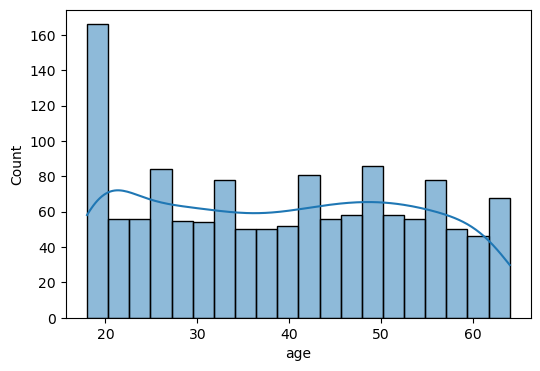

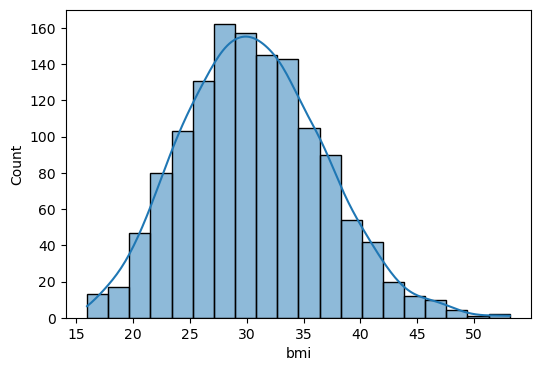

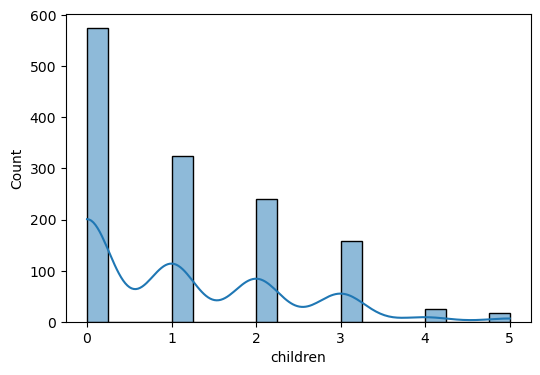

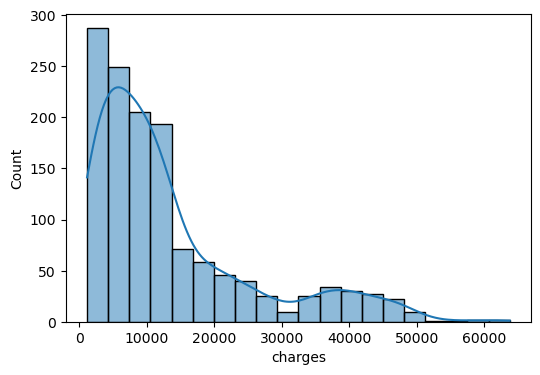

In [10]:
for col in numerical:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

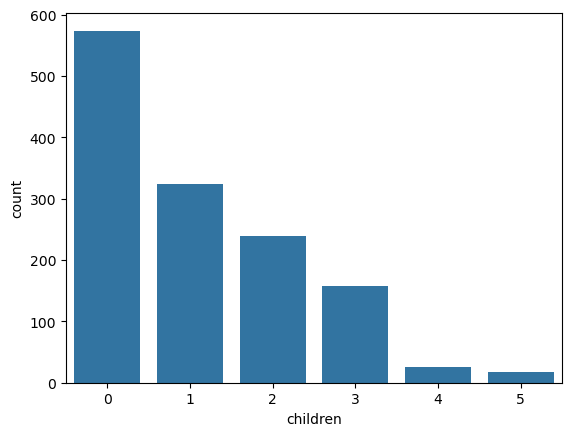

In [11]:
sns.countplot(x= df['children'])

<Axes: xlabel='sex', ylabel='count'>

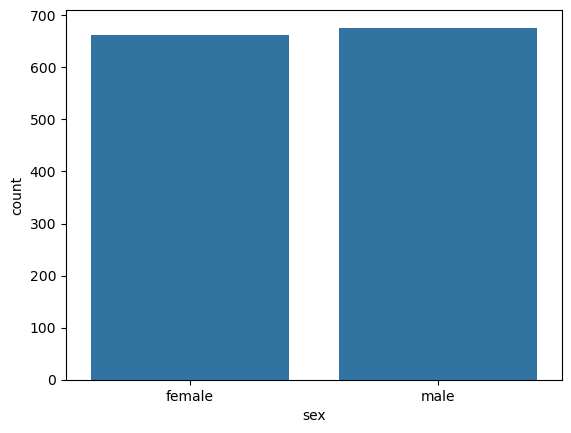

In [12]:
sns.countplot(x= df['sex'])

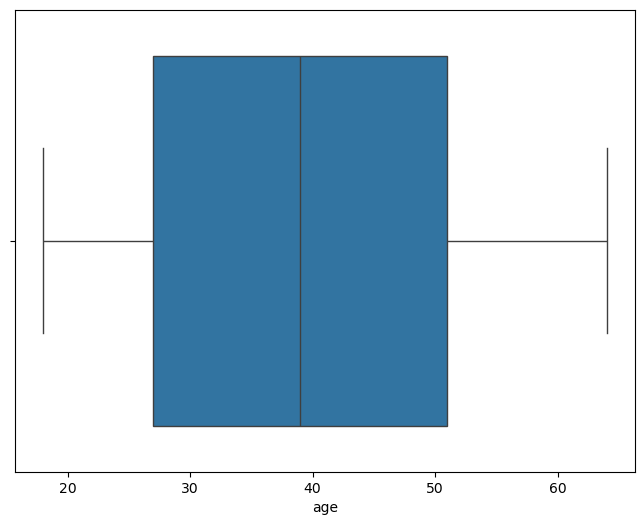

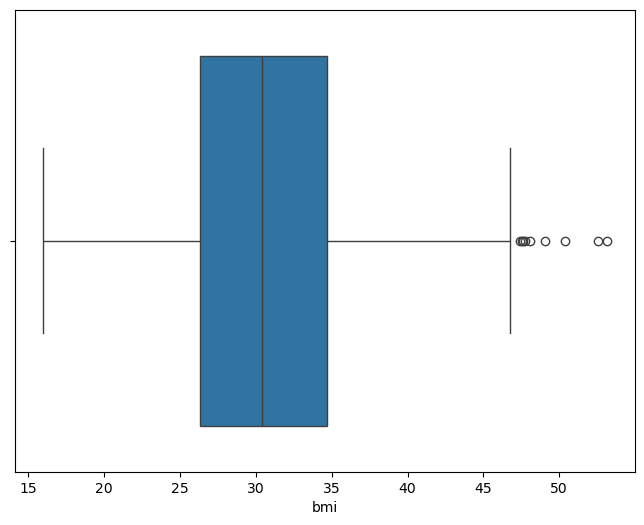

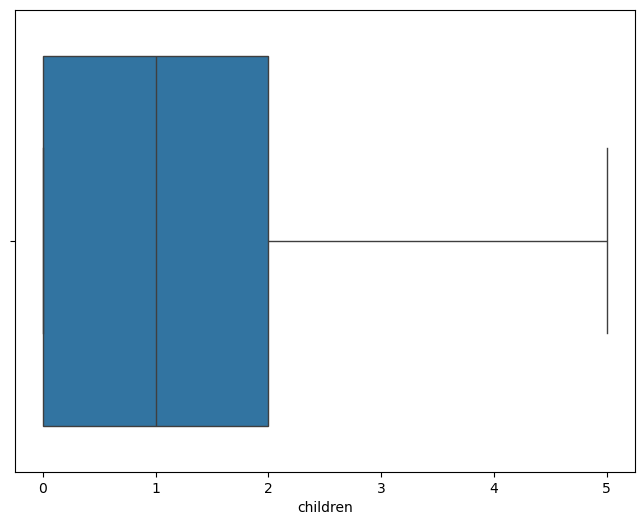

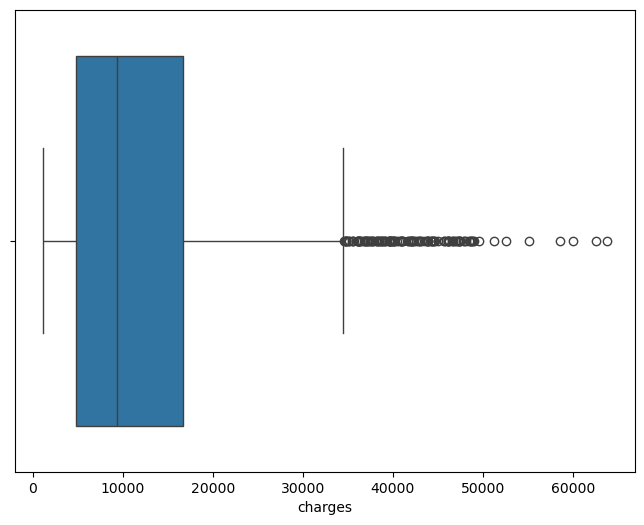

In [13]:
for col in numerical:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])

<Axes: >

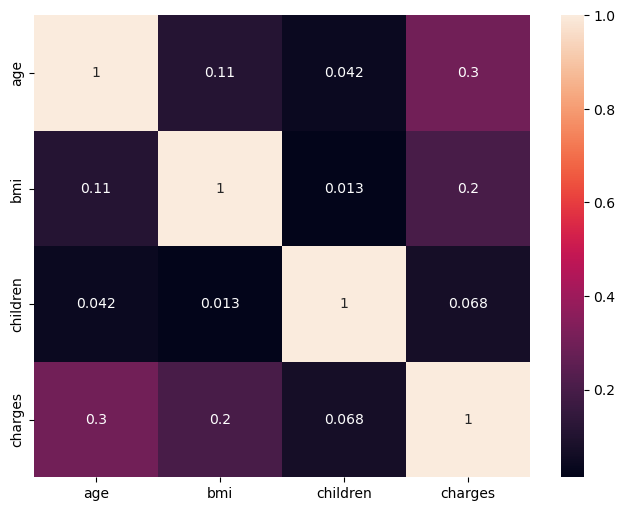

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)


### Data preprocessing and cleaning

In [15]:
df_cleaned = df.copy()

In [16]:
df_cleaned.shape

(1338, 7)

In [17]:
df_cleaned.drop_duplicates(inplace=True)

In [18]:
df_cleaned.shape

(1337, 7)

In [19]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [20]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0,'female':1})

In [21]:
df_cleaned.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [22]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes':1,'no':0})

In [23]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [24]:
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker'
},inplace=True)

In [25]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [26]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'])

In [27]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False
1334,18,1,31.920,0,0,2205.98080,True,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,False,True


In [28]:
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


### Feature engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

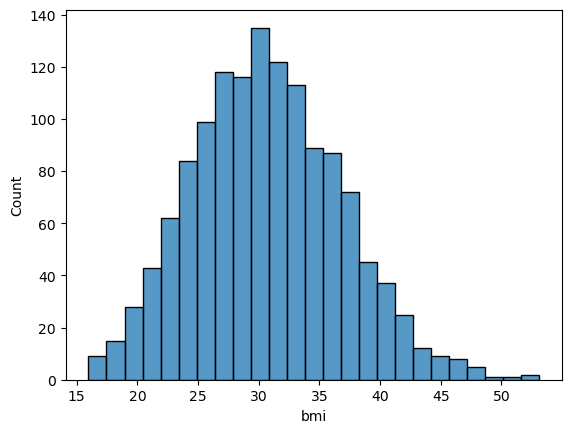

In [29]:
sns.histplot(df_cleaned['bmi'])

In [30]:
df_cleaned['catagory_bmi'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underWeight','Normal','OverWeight','Obese']

)

In [31]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,catagory_bmi
0,19,1,27.900,0,1,16884.92400,False,False,False,True,OverWeight
1,18,0,33.770,1,0,1725.55230,False,False,True,False,Obese
2,28,0,33.000,3,0,4449.46200,False,False,True,False,Obese
3,33,0,22.705,0,0,21984.47061,False,True,False,False,Normal
4,32,0,28.880,0,0,3866.85520,False,True,False,False,OverWeight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False,Obese
1334,18,1,31.920,0,0,2205.98080,True,False,False,False,Obese
1335,18,1,36.850,0,0,1629.83350,False,False,True,False,Obese
1336,21,1,25.800,0,0,2007.94500,False,False,False,True,OverWeight


In [32]:
df_cleaned= pd.get_dummies(df_cleaned, columns=['catagory_bmi'])

In [33]:
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,catagory_bmi_underWeight,catagory_bmi_Normal,catagory_bmi_OverWeight,catagory_bmi_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,0,0,0,1
1334,18,1,31,0,0,2205,1,0,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,0,1,0,0,0,0,1
1336,21,1,25,0,0,2007,0,0,0,1,0,0,1,0


In [34]:
# standard devation of all (distance from the mean )

from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']

scalar = StandardScaler()



In [35]:
df_cleaned[cols] = scalar.fit_transform(df_cleaned[cols])

In [36]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,catagory_bmi_underWeight,catagory_bmi_Normal,catagory_bmi_OverWeight,catagory_bmi_Obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,False,False,False,True,False,False,True,False
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,False,False,True,False,False,False,False,True
2,-0.799350,0,0.383155,1.580143,0,4449.46200,False,False,True,False,False,False,False,True
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,False,True,False,False,False,True,False,False
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,0.050269,1.580143,0,10600.54830,False,True,False,False,False,False,False,True
1334,-1.511647,1,0.206053,-0.909234,0,2205.98080,True,False,False,False,False,False,False,True
1335,-1.511647,1,1.014490,-0.909234,0,1629.83350,False,False,True,False,False,False,False,True
1336,-1.297958,1,-0.797524,-0.909234,0,2007.94500,False,False,False,True,False,False,True,False


In [37]:
from scipy.stats import  pearsonr

# Pearson Correlation Calculation

selected_features = ['age','is_female','bmi','children','is_smoker','region_northeast','region_northwest','region_southeast','region_southwest','catagory_bmi_underWeight','catagory_bmi_Normal','catagory_bmi_OverWeight','catagory_bmi_Obese']

correlation = {
    feature:pearsonr(df_cleaned[feature],df_cleaned['charges'])[0] for feature in selected_features
}

In [38]:
correlation.items()

dict_items([('age', np.float64(0.29830821250978634)), ('is_female', np.float64(-0.05804449579031286)), ('bmi', np.float64(0.19840083122624938)), ('children', np.float64(0.06738935083963252)), ('is_smoker', np.float64(0.7872343672800316)), ('region_northeast', np.float64(0.005945323272979341)), ('region_northwest', np.float64(-0.03869463262101644)), ('region_southeast', np.float64(0.07357792870627781)), ('region_southwest', np.float64(-0.04363736849776149)), ('catagory_bmi_underWeight', np.float64(-0.04822477076836512)), ('catagory_bmi_Normal', np.float64(-0.1056549118470303)), ('catagory_bmi_OverWeight', np.float64(-0.118279404344456)), ('catagory_bmi_Obese', np.float64(0.19765936538425974))])

In [39]:
correlation_df=pd.DataFrame(list(correlation.items()),columns=['Feature', 'Pearson Correlation'])


In [40]:
correlation_df.sort_values(by='Pearson Correlation' ,ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298308
2,bmi,0.198401
12,catagory_bmi_Obese,0.197659
7,region_southeast,0.073578
3,children,0.067389
5,region_northeast,0.005945
6,region_northwest,-0.038695
8,region_southwest,-0.043637
9,catagory_bmi_underWeight,-0.048225


In [41]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,catagory_bmi_underWeight,catagory_bmi_Normal,catagory_bmi_OverWeight,catagory_bmi_Obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,False,False,False,True,False,False,True,False
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,False,False,True,False,False,False,False,True
2,-0.799350,0,0.383155,1.580143,0,4449.46200,False,False,True,False,False,False,False,True
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,False,True,False,False,False,True,False,False
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,0.050269,1.580143,0,10600.54830,False,True,False,False,False,False,False,True
1334,-1.511647,1,0.206053,-0.909234,0,2205.98080,True,False,False,False,False,False,False,True
1335,-1.511647,1,1.014490,-0.909234,0,1629.83350,False,False,True,False,False,False,False,True
1336,-1.297958,1,-0.797524,-0.909234,0,2007.94500,False,False,False,True,False,False,True,False


In [42]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest','region_northeast',
    'catagory_bmi_Normal', 'catagory_bmi_OverWeight', 'catagory_bmi_Obese','catagory_bmi_underWeight'
]

In [43]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }
    
# converting into data fame 
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
catagory_bmi_Obese,7.654464,0.05372,Accept Null (Drop Feature)
region_northeast,6.438442,0.092122,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
catagory_bmi_underWeight,4.384749,0.222804,Accept Null (Drop Feature)
catagory_bmi_Normal,4.263673,0.234364,Accept Null (Drop Feature)
catagory_bmi_OverWeight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [44]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','catagory_bmi_Obese']]

In [45]:
final = final_df.copy()

In [46]:
from sklearn.model_selection import train_test_split
final['region_southeast'] = final['region_southeast'].astype(int)
final['catagory_bmi_Obese'] = final['catagory_bmi_Obese'].astype(int)
final

,age,is_female,bmi,children,is_smoker,charges,region_southeast,catagory_bmi_Obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,0
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,1,1
2,-0.799350,0,0.383155,1.580143,0,4449.46200,1,1
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,0.050269,1.580143,0,10600.54830,0,1
1334,-1.511647,1,0.206053,-0.909234,0,2205.98080,0,1
1335,-1.511647,1,1.014490,-0.909234,0,1629.83350,1,1
1336,-1.297958,1,-0.797524,-0.909234,0,2007.94500,0,0


In [47]:
x = final.drop('charges',axis=1)
y = final['charges']
x

,age,is_female,bmi,children,is_smoker,region_southeast,catagory_bmi_Obese
0,-1.440418,1,-0.453160,-0.909234,1,0,0
1,-1.511647,0,0.509422,-0.079442,0,1,1
2,-0.799350,0,0.383155,1.580143,0,1,1
3,-0.443201,0,-1.305052,-0.909234,0,0,0
4,-0.514431,0,-0.292456,-0.909234,0,0,0
...,...,...,...,...,...,...,...
1333,0.767704,0,0.050269,1.580143,0,0,1
1334,-1.511647,1,0.206053,-0.909234,0,0,1
1335,-1.511647,1,1.014490,-0.909234,0,1,1
1336,-1.297958,1,-0.797524,-0.909234,0,0,0


In [48]:
x_train , x_test , y_train , y_test = train_test_split(x,  y, test_size=.20,random_state=42)

In [49]:
from sklearn.linear_model import LinearRegression

In [50]:
model = LinearRegression()

In [51]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
x = np.array([[35, 1, 28.5, 2, 0, 1, 0]])


In [53]:
y_pred = model.predict(x_test)

In [54]:
y_pred

array([7.83765196e+03, 5.41220098e+03, 1.45734748e+04, 3.24140651e+04,
       8.93974252e+03, 1.33059912e+04, 3.01925744e+04, 1.38524393e+03,
       1.11182549e+04, 1.01350273e+04, 1.07002688e+04, 3.21896796e+04,
       3.15044019e+04, 1.62923443e+04, 1.02592013e+04, 8.60757013e+03,
       5.38975399e+03, 3.23562571e+04, 3.33832244e+03, 3.93203251e+03,
       4.58332078e+03, 2.88320223e+04, 1.39270547e+04, 2.96067006e+04,
       3.14727190e+04, 6.28962422e+03, 3.50019220e+04, 3.78198618e+04,
       1.23800727e+04, 1.42361139e+04, 7.41103553e+03, 1.29684837e+04,
       4.60270928e+02, 1.14096024e+04, 3.76892820e+04, 1.32570630e+04,
       3.80273476e+03, 4.49434217e+03, 3.14030130e+04, 7.97674745e+03,
       6.15246310e+03, 3.02609003e+04, 3.52511558e+04, 1.30002508e+04,
       7.92607495e+03, 3.04042280e+03, 5.21331342e+03, 7.75386743e+03,
       3.59197103e+03, 1.02499437e+04, 7.64046301e+03, 1.06410202e+04,
       3.03064121e+04, 4.57491221e+03, 1.16944956e+04, 1.13062232e+04,
      

In [55]:
y_pred[0]

np.float64(7837.651964830495)

In [56]:
y_test

900      8688.85885
1064     5708.86700
1256    11436.73815
298     38746.35510
237      4463.20510
           ...     
534     13831.11520
542     13887.20400
760      3925.75820
1284    47403.88000
1285     8534.67180
Name: charges, Length: 268, dtype: float64

In [57]:
from sklearn.metrics import r2_score

#### test by r^2 score

In [58]:
r2= r2_score(y_test,y_pred)

In [59]:
# Adjusted R^2 test 
n = x_test.shape[0]
p = x_test.shape[1]

In [60]:
adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)

In [61]:
adjusted_r2

0.7987655812894922